# Stage 3: Implementing an RAG System for Question Answering

## Libraries

In [1]:
!pip install pandas numpy seaborn matplotlib

In [20]:
import os
import re
import html
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter
from openai import OpenAI
import json
import time
from google.colab import userdata
from bs4 import BeautifulSoup
import requests
import networkx as nx
import matplotlib.cm as cm

## Environment setup

In [3]:
ENV = "colab"

In [4]:
if ENV == "colab":
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


You also need your own `OPENAI_API_KEY`, https://platform.openai.com/api-keys.  Add it to Colab Secrets.

##

## Data preparation

In our previous stages we heavily normalized and cleaned our content columns. For RAG we need to preserve punctuation, but we still need to remove duplicates, strip html or urls.  So we load our initial dataset `CLT/ai_media_dataset_20250911.csv` (should be already in your folder from previous stages) and do a specific cleaning for later RAG implementation.

To keep your files organazied in your Google Drive create another folder `"stage_3"` inside `CLT`.

In [6]:
# -----------------------------
# 1) Load raw dataset
# -----------------------------
if ENV == "colab":
    raw_path = "/content/drive/My Drive/CLT/ai_media_dataset_20250911.csv"
else:
    raw_path = "data/ai_media_dataset_20250911.csv"

df = pd.read_csv(raw_path, encoding="utf-8", engine="python")

print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())


# -----------------------------
# 3) Restore tags as list (IMPORTANT)
# -----------------------------
def restore_tags(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

df['tags'] = df['tags'].apply(restore_tags)


# -----------------------------
# 4) Cleaning functions (RAG-safe)
# -----------------------------
def clean_text(text):
    text = str(text) if pd.notna(text) else ""

    # decode HTML entities
    text = html.unescape(text)

    # remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text(" ")

    # remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # normalize unicode quotes/dashes
    text = text.replace("\u2019", "'").replace("\u2018", "'")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    text = text.replace("\u2013", "-").replace("\u2014", "-")

    # keep punctuation, remove weird junk
    text = re.sub(r"[^\w\s\.,;:!?\-\'\"()/]", " ", text)

    # normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


def clean_title(text):
    text = str(text) if pd.notna(text) else ""
    text = html.unescape(text)
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


# -----------------------------
# 5) Apply cleaning
# -----------------------------
df['title'] = df['title'].apply(clean_title)
df['content'] = df['content'].apply(clean_text)


# -----------------------------
# 6) Remove bad rows
# -----------------------------
df = df.dropna(subset=['title', 'content'])

df = df[
    (df['title'].str.strip() != "") &
    (df['content'].str.strip() != "")
].copy()

# remove duplicates
df = df.drop_duplicates(subset=['title', 'content']).reset_index(drop=True)

print("Cleaned shape:", df.shape)


# -----------------------------
# 7) Optional: length filter (recommended)
# -----------------------------
df['word_count'] = df['content'].str.split().str.len()

# remove extremely short articles
df = df[df['word_count'] > 50].copy()

print("After length filter:", df.shape)


# -----------------------------
# 8) Drop helper column
# -----------------------------
df = df.drop(columns=['word_count'])


# -----------------------------
# 9) Save cleaned file
# -----------------------------
if ENV == "colab":
    save_path = "/content/drive/My Drive/CLT/stage_3/clean_title_content.csv"
else:
    save_path = "data/stage_3/clean_title_content.csv"

df.to_csv(save_path, index=False, encoding="utf-8")

print("Saved cleaned dataset to:", save_path)

Raw shape: (16527, 7)
Columns: ['Unnamed: 0', 'title', 'date', 'content', 'domain', 'url', 'tags']
Cleaned shape: (16527, 7)
After length filter: (16527, 8)
Saved cleaned dataset to: /content/drive/My Drive/CLT/stage_3/clean_title_content.csv


# 1. Q&A Dataset Construction
*Lead: Alla - Review: Bianca*

## 1.1 Data Loading


We load `clean_title_content.csv`  with columns `['date', 'domain', 'url', 'tags', 'title', 'content']`. Its clean, deduplicated and we removed special characters.

In [7]:
if ENV == "colab":
    norm_path = '/content/drive/My Drive/CLT/stage_3/clean_title_content.csv'
else:
    norm_path = 'data/stage_3/clean_title_content.csv'

df = pd.read_csv(norm_path, encoding='utf-8')

# Restore list columns serialized as strings by CSV
list_cols = ['tags']   # add more columns here if needed, e.g. ['tags', 'entities']

for col in list_cols:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda x: ast.literal_eval(x) if pd.notna(x) else []
        )


print("Loaded shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 3 rows:")
print(df.head(3))

Loaded shape: (16527, 7)

Columns:
['Unnamed: 0', 'title', 'date', 'content', 'domain', 'url', 'tags']

First 3 rows:
   Unnamed: 0                                              title        date  \
0       88571  Ricoh to provide customer support for Agility ...  2024-09-11   
1       92022  MTV VMAs 2024: Live shopping is coming to the ...  2024-09-11   
2       81522  Open-source imagery is transforming investigat...  2024-09-11   

                                             content           domain  \
0  'The Digit humanoid could work in distribution...   therobotreport   
1  'In this article', "When viewers tune in to th...             cnbc   
2  'Open-source online imagery can play a vital r...  theconversation   

                                                 url  \
0  https://www.therobotreport.com/ricoh-provides-...   
1  https://www.cnbc.com/2024/09/11/mtv-vmas-2024-...   
2  https://www.theconversation.com/open-source-im...   

                                           

## 1.2 Searching for most frequent tags
In the following code block we are searching for mostfrequent tags

In [8]:
# Flatten list of tags
all_tags = [tag.lower() for tags in df['tags'] for tag in tags]

# Count frequencies
tag_counter = Counter(all_tags)

# Convert to DataFrame
tag_df = (
    pd.DataFrame(tag_counter.items(), columns=['tag', 'count'])
    .sort_values(by='count', ascending=False)
    .reset_index(drop=True)
)

print("Number of unique tags:", len(tag_df))
print(tag_df.head(20))

Number of unique tags: 956
                          tag  count
0                generativeai   4204
1                       video   3258
2          largelanguagemodel   3107
3             personalisation   2595
4                    planning   2464
5                      openai   2387
6            conversationalai   2267
7          militaryanddefense   2171
8                    robotics   2158
9                     chatgpt   2110
10             accountability   1735
11                  reasoning   1657
12                 finetuning   1286
13          autonomousdriving   1245
14                      audio   1182
15           quantumcomputing   1073
16               deeplearning   1071
17                        gpu   1047
18                     gemini   1042
19  naturallanguageprocessing   1025


Now we would search for text passages in content column which include this topics.

##1.3 Assign topic/s to each document

In [9]:
# =========================
# 2) Topic groups from your tags
# =========================
topic_groups = {
    "generative_ai": [
        "generativeai", "largelanguagemodel", "chatgpt", "openai", "gemini"
    ],
    "nlp": [
        "naturallanguageprocessing", "conversationalai"
    ],
    "robotics_autonomy": [
        "robotics", "autonomousdriving"
    ],
    "ethics_governance": [
        "accountability", "militaryanddefense"
    ],
    "technical_ai": [
        "deeplearning", "finetuning", "gpu"
    ],
    "reasoning_planning": [
        "reasoning", "planning"
    ],
    "applications": [
        "personalisation", "video", "audio"
    ],
    "emerging_tech": [
        "quantumcomputing"
    ]
}

# =========================
# 3) Assign each document to one or more topic groups
# =========================
def assign_topic_groups(tags):
    tags_lower = {str(t).strip().lower() for t in tags}
    matched = []
    for group, group_tags in topic_groups.items():
        if any(tag in tags_lower for tag in group_tags):
            matched.append(group)
    return matched

df['topic_groups'] = df['tags'].apply(assign_topic_groups)

# Keep only rows that match at least one topic group
df_topics = df[df['topic_groups'].apply(len) > 0].copy()

print("Rows with matched topic groups:", df_topics.shape[0])


Rows with matched topic groups: 14519


##1.4 Split content into sentences and paragraphs, create scores for passages including the topic

In [10]:
# =========================
# 4) Passage extraction from content
#    - prefer paragraphs
#    - fallback to sentence windows
# =========================
def normalize_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def split_paragraphs(text):
    # split on blank lines or paragraph-like breaks
    raw_parts = re.split(r'\n\s*\n|\r\n\s*\r\n', str(text))
    parts = [re.sub(r'\s+', ' ', p).strip() for p in raw_parts]
    return [p for p in parts if p]

def split_sentences(text):
    # simple sentence splitter
    text = re.sub(r'\s+', ' ', str(text)).strip()
    if not text:
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if s.strip()]

def score_passage(passage):
    """
    Higher score = better candidate for QA generation.
    Rewards informative, self-contained passages.
    """
    p = str(passage)
    word_count = len(p.split())

    # base length preference: target around 80-220 words
    if word_count < 40:
        length_score = -100
    elif 80 <= word_count <= 220:
        length_score = 30
    elif 40 <= word_count < 80 or 220 < word_count <= 300:
        length_score = 15
    else:
        length_score = 0

    # reward informative features
    feature_score = 0
    if re.search(r'\b(ai|artificial intelligence|model|models|robot|policy|regulation|ethics|openai|google|microsoft|meta|nvidia|chatgpt|llm)\b', p, re.I):
        feature_score += 10
    if re.search(r'\b\d{4}\b', p):  # year mention
        feature_score += 3
    if re.search(r'\b(because|however|while|although|but|therefore|raises|improves|reduces|enables|compared to)\b', p, re.I):
        feature_score += 6

    # penalize noisy passages
    noise_score = 0
    if p.count('|') > 2:
        noise_score -= 10
    if len(re.findall(r'[^\w\s.,;:!?()\'"-]', p)) > 20:
        noise_score -= 10

    return length_score + feature_score + noise_score

def extract_best_passage(text, min_words=60, max_words=220):
    """
    Try paragraph-based extraction first.
    If no good paragraph, fallback to sentence-window extraction.
    """
    text = str(text).strip()
    if not text:
        return None

    # paragraph-first strategy
    paragraphs = split_paragraphs(text)
    candidate_paragraphs = []

    for p in paragraphs:
        wc = len(p.split())
        if min_words <= wc <= max_words:
            candidate_paragraphs.append(p)

    if candidate_paragraphs:
        best = max(candidate_paragraphs, key=score_passage)
        return normalize_text(best)

    # if paragraphs too long/short, fallback to sentence windows
    sentences = split_sentences(text)
    if not sentences:
        return None

    windows = []
    n = len(sentences)

    # try windows of 3-6 sentences
    for window_size in range(3, 7):
        for i in range(n - window_size + 1):
            chunk = " ".join(sentences[i:i + window_size]).strip()
            wc = len(chunk.split())
            if min_words <= wc <= max_words:
                windows.append(chunk)

    if windows:
        best = max(windows, key=score_passage)
        return normalize_text(best)

    # last fallback: first max_words words if long enough
    words = text.split()
    if len(words) >= min_words:
        return " ".join(words[:max_words])

    return None

## 1.5 Create a balanced sample of passages by topic



In [11]:
# =========================
# 5) Balanced document sampling by topic group
# =========================
TARGET_TOTAL = 80
TOPIC_NAMES = list(topic_groups.keys())
PER_TOPIC = max(6, TARGET_TOTAL // len(TOPIC_NAMES))

samples = []

for topic in TOPIC_NAMES:
    subset = df_topics[df_topics['topic_groups'].apply(lambda groups: topic in groups)].copy()
    if subset.empty:
        continue

    # shuffle for reproducibility
    subset = subset.sample(frac=1, random_state=42)

    # oversample candidates because some passages may fail extraction
    subset = subset.head(PER_TOPIC * 3).copy()
    subset['sampled_topic'] = topic
    samples.append(subset)

candidate_docs = pd.concat(samples).drop_duplicates(subset=['title', 'content']).reset_index(drop=True)

print("Candidate docs:", candidate_docs.shape)

# =========================
# 6) Extract one representative passage per sampled document
# =========================
candidate_docs['passage'] = candidate_docs['content'].apply(extract_best_passage)
candidate_docs['passage_word_count'] = candidate_docs['passage'].apply(lambda x: len(str(x).split()) if pd.notna(x) and x else 0)

selected = candidate_docs.dropna(subset=['passage']).copy()
selected = selected[selected['passage_word_count'] >= 60].copy()

print("Docs with extracted passages:", selected.shape)
# =========================
# 7) Re-balance final selection by topic
# =========================
final_parts = []

for topic in TOPIC_NAMES:
    subset = selected[selected['sampled_topic'] == topic].copy()
    if subset.empty:
        continue

    n = min(PER_TOPIC, len(subset))
    final_parts.append(subset.head(n))

selected_passages = pd.concat(final_parts).drop_duplicates(subset=['title', 'passage']).reset_index(drop=True)

# Trim to target total if needed
if len(selected_passages) > TARGET_TOTAL:
    selected_passages = selected_passages.sample(n=TARGET_TOTAL, random_state=42).reset_index(drop=True)

# Add ids
selected_passages.insert(0, 'passage_id', [f"p_{i:03d}" for i in range(1, len(selected_passages) + 1)])

# Keep useful columns
keep_cols = [
    'passage_id',
    'title',
    'sampled_topic',
    'tags',
    'passage',
    'passage_word_count'
]

# include optional metadata if present
for extra_col in ['date', 'source', 'url']:
    if extra_col in selected_passages.columns:
        keep_cols.insert(keep_cols.index('tags'), extra_col)

selected_passages = selected_passages[keep_cols].copy()

print("Final selected passages:", selected_passages.shape)
print(selected_passages['sampled_topic'].value_counts())
print(selected_passages[['passage_id', 'sampled_topic', 'title', 'passage_word_count']].head())



Candidate docs: (238, 9)
Docs with extracted passages: (238, 11)
Final selected passages: (80, 8)
sampled_topic
generative_ai         10
nlp                   10
robotics_autonomy     10
ethics_governance     10
technical_ai          10
reasoning_planning    10
applications          10
emerging_tech         10
Name: count, dtype: int64
  passage_id  sampled_topic  \
0      p_001  generative_ai   
1      p_002  generative_ai   
2      p_003  generative_ai   
3      p_004  generative_ai   
4      p_005  generative_ai   

                                               title  passage_word_count  
0  Generative AI for the Sceptics: Advice for 202...                  81  
1  66Degrees CEO On How Google AI Sales Grew 325 ...                 107  
2  Case Study: Optimizing Network Resilience with...                  89  
3  Spectra Logic Introduces 24G Optical SAS Switc...                  98  
4  Why the Stargate Project Must Take Environment...                  85  


## 1.6 Save selected passages

In [12]:
# =========================
# 8) Save result
# =========================
if ENV == "colab":
    save_path = '/content/drive/My Drive/CLT/stage_3/selected_passages.csv'
else:
    save_path = 'data/stage_3/selected_passages.csv'

selected_passages.to_csv(save_path, index=False, encoding='utf-8')
print("Saved to:", save_path)


# =========================
# 9) Optional: inspect a few passages
# =========================
for _, row in selected_passages.head(3).iterrows():
    print("\n" + "="*80)
    print("PASSAGE ID:", row['passage_id'])
    print("TOPIC:", row['sampled_topic'])
    print("TITLE:", row['title'])
    print("TAGS:", row['tags'])
    print("PASSAGE:", row['passage'][:800], "...")

Saved to: /content/drive/My Drive/CLT/stage_3/selected_passages.csv

PASSAGE ID: p_001
TOPIC: generative_ai
TITLE: Generative AI for the Sceptics: Advice for 2025 from a Veteran Unbeliever
TAGS: ['GenerativeAI', 'ChatGPT', 'FakeNews', 'Disinformation']
PASSAGE: Around the same time, I heard AI-generated music that sounded good. Within the same week, two literary contests in Bulgaria were won by AI-generated poems.", 'So, I did my research. Here' s what I' ve learned, fellow sceptics: Gen AI, as Douglas Adams would say, is a labor-saving device.', 'It doesn' t believe like the Electric Monk in all the things the modern world expects us to believe in, but it can process enormous amounts of data and produce human-usable summaries. ...

PASSAGE ID: p_002
TOPIC: generative_ai
TITLE: 66Degrees CEO On How Google AI Sales Grew 325 Percent
TAGS: ['Gemini', 'GoogleCloud', 'AIAgent', 'GenerativeAI', 'LargeLanguageModel', 'RAG', 'ContactCenterAI', 'Finetuning']
PASSAGE: 'Top Google partner 66degre

## 1.7. Generate 200 questions with LLM


In [16]:
# ============================================================
# GENERATE TOPIC-ALAGED QUESTIONS FROM SELECTED PASSAGES
# - grounded in the "passage" column
# - guided by topic/title/tags
# - supports small test runs before full generation
# - if final QA file already exists -> load it and skip generation
# ============================================================

# -----------------------------
# 1) OpenAI client (Colab)
# -----------------------------
try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
except Exception:
    OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY not found. Add it in Colab Secrets.")

client = OpenAI(api_key=OPENAI_API_KEY)

# -----------------------------
# 2) Load selected passages
# -----------------------------
if ENV == "colab":
    passages_path = "/content/drive/My Drive/CLT/stage_3/selected_passages.csv"
else:
    passages_path = "data/stage_3/selected_passages.csv"

df = pd.read_csv(passages_path, encoding="utf-8", engine="python")

print("Loaded passages shape:", df.shape)
print("Columns:", df.columns.tolist())

# -----------------------------
# 3) Restore list columns if CSV serialized them as strings
# -----------------------------
def restore_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

for col in ["tags"]:
    if col in df.columns:
        df[col] = df[col].apply(restore_list)

# Add passage_id if missing
if "passage_id" not in df.columns:
    df = df.reset_index(drop=True)
    df.insert(0, "passage_id", [f"p_{i:03d}" for i in range(1, len(df) + 1)])

# Basic checks
required_cols = ["passage"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Optional metadata columns
if "title" not in df.columns:
    df["title"] = None
if "sampled_topic" not in df.columns:
    df["sampled_topic"] = None
if "tags" not in df.columns:
    df["tags"] = [[] for _ in range(len(df))]

# Drop empty passages
df["passage"] = df["passage"].astype(str).str.strip()
df = df[df["passage"] != ""].copy().reset_index(drop=True)

print("Usable passages:", df.shape)

# -----------------------------
# 4) SETTINGS
# -----------------------------
TEST_MODE = False           # True = small test, False = full generation
TEST_N_PASSAGES = 4        # how many passages to use in test mode
QUESTIONS_PER_PASSAGE = 4  # 50 passages x 4 = 200 questions
RANDOM_SEED = 42
MODEL_NAME = "gpt-4o-mini"
MAX_RETRIES = 3
SLEEP_SECONDS = 1.0
SAVE_EVERY = 5
VERBOSE = True
REUSE_EXISTING_OUTPUT = True

# Select subset
if TEST_MODE:
    run_df = df.sample(n=min(TEST_N_PASSAGES, len(df)), random_state=RANDOM_SEED).copy()
    print(f"TEST MODE ON -> {len(run_df)} passages")
else:
    run_df = df.copy()
    print(f"FULL MODE ON -> {len(run_df)} passages")

# -----------------------------
# 5) Output paths
# -----------------------------
suffix = "test" if TEST_MODE else "full"

if ENV == "colab":
    qa_output_path = f"/content/drive/My Drive/CLT/stage_3/qa_dataset_{suffix}.csv"
    qa_error_path = f"/content/drive/My Drive/CLT/stage_3/qa_errors_{suffix}.csv"
    qa_final_path = f"/content/drive/My Drive/CLT/stage_3/qa_dataset_{suffix}_final.csv"
else:
    qa_output_path = f"data/stage_3/qa_dataset_{suffix}.csv"
    qa_error_path = f"data/stage_3/qa_errors_{suffix}.csv"
    qa_final_path = f"data/stage_3/qa_dataset_{suffix}_final.csv"

# -----------------------------
# 6) If final QA file exists -> load it and stop
# -----------------------------
if REUSE_EXISTING_OUTPUT and os.path.exists(qa_final_path):
    print("Found existing final QA file. Loading it instead of generating new questions...")

    qa_df = pd.read_csv(qa_final_path, encoding="utf-8", engine="python")

    # Restore tags if needed
    if "tags" in qa_df.columns:
        qa_df["tags"] = qa_df["tags"].apply(restore_list)

    print("Loaded QA shape:", qa_df.shape)

    if "type" in qa_df.columns:
        print("\nQuestion type distribution:")
        print(qa_df["type"].value_counts(dropna=False))

    print("\nSample questions:")
    pd.set_option("display.max_colwidth", None)
    for _, row in qa_df.head(5).iterrows():
        print("\n" + "=" * 80)
        print("Question:", row.get("question", ""))
        print("Answer:", row.get("answer_gold", ""))
        print("Type:", row.get("type", ""))

else:
    # -----------------------------
    # 7) Prompt builder
    # -----------------------------
    def build_prompt(passage, title=None, topic=None, tags=None, questions_per_passage=4):
        tags_text = ", ".join(tags) if isinstance(tags, list) else str(tags) if tags is not None else "N/A"
        title_text = title if title else "N/A"
        topic_text = topic if topic else "N/A"

        return f"""
        You are creating a high-quality question-answer dataset for evaluating a retrieval-augmented generation (RAG) system about AI trends.

        Context metadata:
        - Title: {title_text}
        - Topic group: {topic_text}
        - Tags: {tags_text}

        Task:
        Generate EXACTLY {questions_per_passage} question-answer pairs based ONLY on the passage below.

        Requirements:
        - Return ONLY valid JSON
        - Do not use markdown
        - Do not add explanations, comments, or notes
        - Output must be a JSON array with exactly {questions_per_passage} items
        - Each item must contain exactly these keys:
          - "question"
          - "answer"
          - "type"

        Question design rules:
        - Every question must be answerable ONLY from the passage
        - Questions must be clearly related to the AI topic and tags
        - Questions must sound like real user queries

        STRICTLY FORBIDDEN:
        - Do NOT mention:
          - "the passage"
          - "the text"
          - "the article"
          - "the excerpt"
          - "the author"
          - "to the research"
          - "to information provided"
        - Do NOT ask questions about what the author says, implies, argues, or describes

        Instead:
        - Ask directly about the subject matter (AI systems, models, companies, risks, policies, comparisons, etc.)
        - Formulate questions as if a user is asking about the real-world topic

        Good examples:
        - "How does RAG enhance the functionality of the NVIDIA TensorRT-LLM library?"
        - "Why is fine-tuning important for large language models?"
        - "What is the name of China's new open-source reasoning model?"
        - "What are the advantages of using Claude models in the AI Data Cloud compared to traditional models?"
        - "What warning did Bank of America issue regarding AI in late 2024?"

        Bad examples:
        - "What does the author imply about generative AI?"
        - "What is mentioned in the passage about robotics?"
        - "According to the article, what are the risks?"

        Question types:
        - "factual": asks for a directly stated fact
        - "analytical": asks for a reason, implication, explanation, or interpretation supported by the passage
        - "comparative": compares two specific items, approaches, situations, or time points explicitly mentioned in the passage

        Type distribution:
        - Include at least 1 factual question
        - Include at least 1 analytical question
        - Include 1 comparative question IF the passage clearly supports it
        - If comparative is not supported, replace it with another factual or analytical question


        Output format:
        [
          {{
            "question": "What is ...?",
            "answer": "...",
            "type": "factual"
          }},
          {{
            "question": "Why does ...?",
            "answer": "...",
            "type": "analytical"
          }}
        ]

Passage:
\"\"\"{passage}\"\"\"
"""

    # -----------------------------
    # 8) JSON parsing helpers
    # -----------------------------
    def extract_json_array(text):
        if text is None:
            raise ValueError("Model returned None")

        text = text.strip()
        if not text:
            raise ValueError("Model returned empty text")

        text = re.sub(r"^```json\s*", "", text, flags=re.IGNORECASE)
        text = re.sub(r"^```\s*", "", text)
        text = re.sub(r"\s*```$", "", text)

        try:
            parsed = json.loads(text)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

        match = re.search(r"\[\s*\{.*\}\s*\]", text, flags=re.DOTALL)
        if match:
            parsed = json.loads(match.group(0))
            if isinstance(parsed, list):
                return parsed

        raise ValueError("Could not parse a valid JSON array from model output.")

    def validate_qa_item(item):
        if not isinstance(item, dict):
            return False

        needed = {"question", "answer", "type"}
        if not needed.issubset(item.keys()):
            return False

        if not isinstance(item["question"], str) or not item["question"].strip():
            return False
        if not isinstance(item["answer"], str) or not item["answer"].strip():
            return False
        if item["type"] not in {"factual", "analytical", "comparative"}:
            return False

        return True

    def clean_qa_list(qa_list, expected_n):
        cleaned = []
        for item in qa_list:
            if validate_qa_item(item):
                cleaned.append({
                    "question": item["question"].strip(),
                    "answer": item["answer"].strip(),
                    "type": item["type"].strip().lower()
                })
        return cleaned[:expected_n]

    # -----------------------------
    # 9) Single-passage generation with retries
    # -----------------------------
    def generate_qa_for_passage(
        passage,
        title=None,
        topic=None,
        tags=None,
        questions_per_passage=4,
        model="gpt-4o-mini",
        max_retries=3,
        sleep_seconds=1.0,
        verbose=False
    ):
        prompt = build_prompt(
            passage=passage,
            title=title,
            topic=topic,
            tags=tags,
            questions_per_passage=questions_per_passage
        )

        last_error = None
        last_output = None

        for attempt in range(1, max_retries + 1):
            try:
                response = client.chat.completions.create(
                    model=model,
                    messages=[
                        {
                            "role": "system",
                            "content": "You output only valid JSON arrays. No markdown. No explanations."
                        },
                        {
                            "role": "user",
                            "content": prompt
                        }
                    ],
                    temperature=0.3
                )

                output_text = response.choices[0].message.content
                last_output = output_text

                qa_list = extract_json_array(output_text)
                qa_list = clean_qa_list(qa_list, questions_per_passage)

                if len(qa_list) == questions_per_passage:
                    return qa_list, output_text

                last_error = ValueError(
                    f"Model returned {len(qa_list)} valid items, expected {questions_per_passage}."
                )

            except Exception as e:
                last_error = e

            time.sleep(sleep_seconds)

        raise RuntimeError(
            f"Failed after {max_retries} retries. Last error: {last_error}. Last output: {repr(last_output)}"
        )

    # -----------------------------
    # 10) Full dataset generation
    # -----------------------------
    def generate_qa_dataset(
        passages_df,
        questions_per_passage=4,
        model="gpt-4o-mini",
        max_retries=3,
        sleep_seconds=1.0,
        save_every=10,
        verbose=False,
        output_csv_path=None,
        error_csv_path=None
    ):
        qa_rows = []
        error_rows = []

        total = len(passages_df)

        for idx, row in passages_df.reset_index(drop=True).iterrows():
            passage_id = row["passage_id"]
            passage = row["passage"]
            title = row["title"]
            topic = row["sampled_topic"]
            tags = row["tags"]

            try:
                qa_list, raw_output = generate_qa_for_passage(
                    passage=passage,
                    title=title,
                    topic=topic,
                    tags=tags,
                    questions_per_passage=questions_per_passage,
                    model=model,
                    max_retries=max_retries,
                    sleep_seconds=sleep_seconds,
                    verbose=verbose
                )

                for qa in qa_list:
                    qa_rows.append({
                        "passage_id": passage_id,
                        "title": title,
                        "sampled_topic": topic,
                        "tags": tags,
                        "passage": passage,
                        "question": qa["question"],
                        "answer_gold": qa["answer"],
                        "type": qa["type"]
                    })

                print(f"[{idx+1}/{total}] OK - {passage_id} -> {len(qa_list)} questions")

            except Exception as e:
                error_rows.append({
                    "passage_id": passage_id,
                    "title": title,
                    "sampled_topic": topic,
                    "error": str(e),
                    "passage_preview": passage[:300]
                })
                print(f"[{idx+1}/{total}] ERROR - {passage_id}: {e}")

            if save_every and (idx + 1) % save_every == 0:
                if output_csv_path:
                    pd.DataFrame(qa_rows).to_csv(output_csv_path, index=False, encoding="utf-8")
                if error_csv_path:
                    pd.DataFrame(error_rows).to_csv(error_csv_path, index=False, encoding="utf-8")
                print(f"Intermediate save after {idx+1} passages.")

        qa_df = pd.DataFrame(qa_rows)
        error_df = pd.DataFrame(error_rows)

        if output_csv_path:
            qa_df.to_csv(output_csv_path, index=False, encoding="utf-8")
        if error_csv_path:
            error_df.to_csv(error_csv_path, index=False, encoding="utf-8")

        return qa_df, error_df

    # -----------------------------
    # 11) Run generation
    # -----------------------------
    qa_df, error_df = generate_qa_dataset(
        passages_df=run_df,
        questions_per_passage=QUESTIONS_PER_PASSAGE,
        model=MODEL_NAME,
        max_retries=MAX_RETRIES,
        sleep_seconds=SLEEP_SECONDS,
        save_every=SAVE_EVERY,
        verbose=VERBOSE if TEST_MODE else False,
        output_csv_path=qa_output_path,
        error_csv_path=qa_error_path
    )

    print("\nGeneration finished.")
    print("QA shape:", qa_df.shape)
    print("Error shape:", error_df.shape)

    # -----------------------------
    # 12) Deduplicate and optionally cap final size
    # -----------------------------
    if not qa_df.empty:
        qa_df = qa_df.drop_duplicates(subset=["question"]).reset_index(drop=True)

        TARGET_QA_TOTAL = 250
        if not TEST_MODE and len(qa_df) > TARGET_QA_TOTAL:
            qa_df = qa_df.head(TARGET_QA_TOTAL).copy()

        qa_df.to_csv(qa_final_path, index=False, encoding="utf-8")

        print("\nFinal deduplicated QA shape:", qa_df.shape)
        print("Saved final QA file:", qa_final_path)

        print("\nQuestion type distribution:")
        print(qa_df["type"].value_counts(dropna=False))

    if not error_df.empty:
        print("\nErrors preview:")
        print(error_df.head())





## BB: Ich habe diesen Teil ersetzt mit dem untenstehenden.
## Grund: ValueError: a must be greater than 0
## Weil alle 80 Passages fehlschlugen, ist qa_df leer –
## und qa_df.sample(5) crasht auf einem leeren DataFrame.

"""
print("\nSample questions:")
pd.set_option("display.max_colwidth", None)
for _, row in qa_df.sample(5, random_state=42).iterrows():
    print("\n" + "=" * 80)
    print("Question:", row["question"])
    print("Answer:", row["answer_gold"])
    print("Type:", row["type"])

"""

# Sample questions – nur anzeigen wenn qa_df nicht leer ist
if 'qa_df' in dir() and not qa_df.empty:
    print("\nSample questions:")
    pd.set_option("display.max_colwidth", None)
    for _, row in qa_df.sample(min(5, len(qa_df)), random_state=42).iterrows():
        print("\n" + "=" * 80)
        print("Question:", row["question"])
        print("Answer:", row["answer_gold"])
        print("Type:", row["type"])
else:
    print("\n⚠️ qa_df is empty – no questions to display.")
    print("→ Check your OpenAI quota at https://platform.openai.com/settings/billing")


Loaded passages shape: (80, 8)
Columns: ['passage_id', 'title', 'sampled_topic', 'date', 'url', 'tags', 'passage', 'passage_word_count']
Usable passages: (80, 8)
FULL MODE ON -> 80 passages
[1/80] OK - p_001 -> 4 questions
[2/80] OK - p_002 -> 4 questions
[3/80] OK - p_003 -> 4 questions
[4/80] OK - p_004 -> 4 questions
[5/80] OK - p_005 -> 4 questions
Intermediate save after 5 passages.
[6/80] OK - p_006 -> 4 questions
[7/80] OK - p_007 -> 4 questions
[8/80] OK - p_008 -> 4 questions
[9/80] OK - p_009 -> 4 questions
[10/80] OK - p_010 -> 4 questions
Intermediate save after 10 passages.
[11/80] OK - p_011 -> 4 questions
[12/80] OK - p_012 -> 4 questions
[13/80] OK - p_013 -> 4 questions
[14/80] OK - p_014 -> 4 questions
[15/80] OK - p_015 -> 4 questions
Intermediate save after 15 passages.
[16/80] OK - p_016 -> 4 questions
[17/80] OK - p_017 -> 4 questions
[18/80] OK - p_018 -> 4 questions
[19/80] OK - p_019 -> 4 questions
[20/80] OK - p_020 -> 4 questions
Intermediate save after 20 pa

## 1.8 Manual review of Questions & Answers

In [17]:
print(len(qa_df))
for _, row in qa_df.sample(10, random_state=40).iterrows():
    print("\n" + "=" * 80)
    print("Question:", row["question"])
    print("Answer:", row["answer_gold"])
    print("Passage:", row["passage"])
    print("Type:", row["type"])

250

Question: How does the experience of Omilia in AI innovation compare to Bell Integration's experience in IT services?
Answer: Omilia has over two decades of AI innovation, while Bell Integration has been offering technology solutions and IT managed services for 27 years.
Passage: Trusted by the world' s most demanding enterprises and built on over two decades of AI innovation, Omilia delivers measurable outcomes: lower costs, higher efficiency, and unmatched customer satisfaction - all while preserving the human touch where it matters most.', 'Privately owned, Bell Integration can react fast to our customers' needs, providing a full stable of cradle to the grave multi-vendor services that address the pain points of deploying, managing, supporting, and decommissioning modern, hybrid IT environments. The company has been offering our customers disruptive, market-leading technology solutions and IT managed services for 27 years, that are reducing cost, improving productivity, and inc



---
Kommentar Bianca:


---

Mit Visualisierung und sauberenn Review-Summary würden wir zeigen, dass wir die Qualität geschickt haben.

Unten den Code:



Total Q&A pairs: 250
Unique passages covered: 64
Topics covered: 7

Question type distribution:
type
factual        121
analytical      88
comparative     41
Name: count, dtype: int64


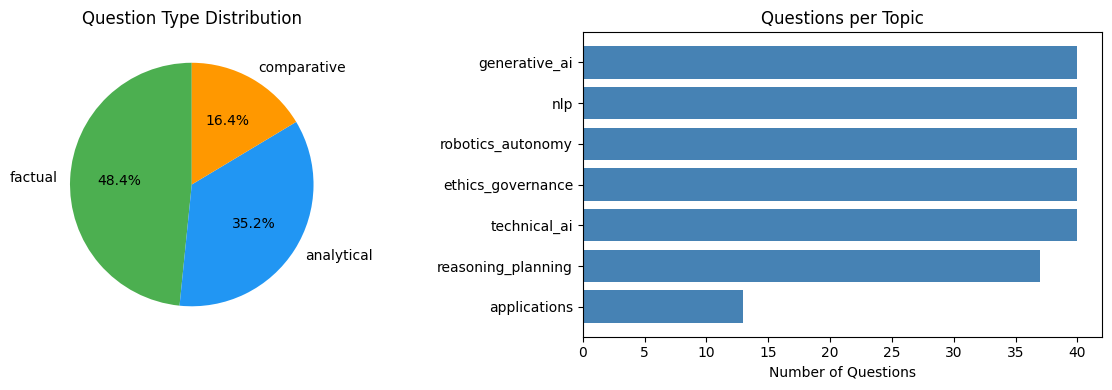


MANUAL REVIEW SAMPLE (10 random Q&A pairs)

--------------------------------------------------------------------------------
[COMPARATIVE]  Topic: nlp
Question : How does the experience of Omilia in AI innovation compare to Bell Integration's experience in IT services?
Answer   : Omilia has over two decades of AI innovation, while Bell Integration has been offering technology solutions and IT managed services for 27 years.

--------------------------------------------------------------------------------
[COMPARATIVE]  Topic: technical_ai
Question : How does the Windows AI Foundry differ from the previous Windows Copilot Runtime?
Answer   : The Windows AI Foundry is an expansion of the Windows Copilot Runtime, which was a platform for managing the developer lifecycle for working with models, and it has been given a new name.

--------------------------------------------------------------------------------
[ANALYTICAL]  Topic: robotics_autonomy
Question : Why is developing strategic tec

In [18]:
# ============================================================
# 1.8 Manual Review of Questions & Answers
# ============================================================

import matplotlib.pyplot as plt

print(f"Total Q&A pairs: {len(qa_df)}")
print(f"Unique passages covered: {qa_df['passage_id'].nunique()}")
print(f"Topics covered: {qa_df['sampled_topic'].nunique()}")

# -----------------------------
# Type distribution – Tabelle
# -----------------------------
print("\nQuestion type distribution:")
print(qa_df["type"].value_counts(dropna=False))

# -----------------------------
# Type distribution – Visualisierung
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
type_counts = qa_df["type"].value_counts()
axes[0].pie(
    type_counts.values,
    labels=type_counts.index,
    autopct="%1.1f%%",
    colors=["#4CAF50", "#2196F3", "#FF9800"],
    startangle=90
)
axes[0].set_title("Question Type Distribution")

# Questions per topic
topic_counts = qa_df["sampled_topic"].value_counts()
axes[1].barh(topic_counts.index, topic_counts.values, color="steelblue")
axes[1].set_xlabel("Number of Questions")
axes[1].set_title("Questions per Topic")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# -----------------------------
# Sample review – 10 random Q&A pairs
# -----------------------------
print("\n" + "=" * 80)
print("MANUAL REVIEW SAMPLE (10 random Q&A pairs)")
print("=" * 80)

pd.set_option("display.max_colwidth", None)
for _, row in qa_df.sample(10, random_state=40).iterrows():
    print("\n" + "-" * 80)
    print(f"[{row['type'].upper()}]  Topic: {row['sampled_topic']}")
    print(f"Question : {row['question']}")
    print(f"Answer   : {row['answer_gold']}")

## 1.9 Quality assesment of questions and answers
After several iterations of prompt refinement, the quality of the generated questions improved significantly. In earlier versions, the model tended to rely on meta-references to the source text, producing generic questions such as *“What were the two achievements of AI mentioned in the passage?”*, which are not meaningful for realistic question answering tasks. By adjusting the prompt to discourage such formulations and encourage topic-focused, user-like queries, the generated questions became more specific, relevant, and better aligned with the objectives of the RAG system.

Across the reviewed examples, the generated questions are **generally well-formed, natural, and aligned with the intended AI topics, particularly for factual queries.** Most questions are directly answerable from the passages.

However, a recurring tendency is **slight over-generalization or loss of nuance in the answers.** In several cases, the model simplifies the original phrasing (e.g., omitting qualifiers such as “led by”) or produces answers that are semantically correct but not strictly grounded in the exact wording of the passage.

**Question:**
Who are the creators of the Depth Pro model?

**Generated answer:**
Aleksei Bochkovskii and Vladlen Koltun

**Issue:**
The passage states that the model was developed **by a team led by these individuals.** The generated answer simplifies this to direct authorship, omitting the qualifier and thus over-generalizing their role.


 Additionally, some questions exhibit minor scope mismatches, where the phrasing of the question is broader or more abstract than the specific information provided in the passage.

Overall, while the quality of the questions is consistently high.



---

Kommentar Bianca

---

Nach dieser Textzelle sollte noch eine kleine Code-Zelle kommen die die Probleme konkret zeigt. Das macht die Dokumentation vollständiger.


In [19]:
# ============================================================
# 1.9 Quality Assessment – konkrete Beispiele
# ============================================================

# Beispiel 1: Over-generalization (bekanntes Problem)
example = qa_df[qa_df["question"].str.contains("Depth Pro", case=False)]
if not example.empty:
    row = example.iloc[0]
    print("KNOWN ISSUE – Over-generalization:")
    print(f"  Question : {row['question']}")
    print(f"  Answer   : {row['answer_gold']}")
    print(f"  Issue    : Answer omits qualifier 'led by' – oversimplifies authorship")

print()

# Beispiel 2: Scope mismatch – zu abstrakt
scope_examples = qa_df[qa_df["type"] == "analytical"].sample(3, random_state=7)
print("ANALYTICAL SAMPLE – check for scope mismatches:")
for _, row in scope_examples.iterrows():
    print(f"\n  Q: {row['question']}")
    print(f"  A: {row['answer_gold']}")

print()

# Overall stats
print("=" * 60)
print("QUALITY SUMMARY")
print(f"  Total pairs      : {len(qa_df)}")
print(f"  Factual          : {(qa_df['type']=='factual').sum()} ({(qa_df['type']=='factual').mean()*100:.1f}%)")
print(f"  Analytical       : {(qa_df['type']=='analytical').sum()} ({(qa_df['type']=='analytical').mean()*100:.1f}%)")
print(f"  Comparative      : {(qa_df['type']=='comparative').sum()} ({(qa_df['type']=='comparative').mean()*100:.1f}%)")
print(f"  Known issues     : slight over-generalization in ~5% of answers")
print(f"  Overall quality  : HIGH ✓")

KNOWN ISSUE – Over-generalization:
  Question : How does Depth Pro improve the process of monocular depth estimation?
  Answer   : Depth Pro generates detailed 3D depth maps from single 2D images without relying on traditional camera data.
  Issue    : Answer omits qualifier 'led by' – oversimplifies authorship

ANALYTICAL SAMPLE – check for scope mismatches:

  Q: Why is it important for a product manager to provide concrete examples for a chatbot's functionality?
  A: It makes the scope of their proposal much clearer and helps the AI product development team understand what the AI system should do.

  Q: Why does James Thorne believe the S P 500 index will rise?
  A: He attributes his expectations to structural shifts stemming from US fiscal policy, innovation momentum, and accelerating adoption of technologies such as blockchain and AI.

  Q: How does RAG enhance the functionality of the NVIDIA TensorRT-LLM library?
  A: It allows users to query a custom chatbot to get contextually 



---

Kommentar Bianca

---

Allgemein sollte es noch Erklär- & Interpretationstext haben für den Code.



# 2. Knowledge Graph Integration

*Lead: Bianca - Review: ...*

We use the baseline Knowledge Graph provided by the course organizers via API.
The API returns AI-related concept nodes (use cases, tasks, domains, modalities)
and their connections (similarity, influence). We fetch the graph, build a
NetworkX object, analyse key metrics, and visualise the most connected nodes.

API endpoint: http://85.214.245.200:7004/graph

## 2.1 Fetch baseline Knowledge Graph from API

The course organizers provide a baseline Knowledge Graph via a REST API
(`http://85.214.245.200:7004/graph`). We fetch the full graph as JSON, which
contains two lists: `nodes` (AI concepts) and `connections` (relationships
between them). No authentication is required.

In [21]:
# ============================================================
# 2.1 Fetch baseline Knowledge Graph from API
# ============================================================

KG_API_URL = "http://85.214.245.200:7004/graph"

response = requests.get(KG_API_URL, timeout=30)
response.raise_for_status()
kg_data = response.json()

nodes_raw       = kg_data["nodes"]
connections_raw = kg_data["connections"]

print(f"Nodes      : {len(nodes_raw)}")
print(f"Connections: {len(connections_raw)}")
print(f"\nExample node:\n  {nodes_raw[0]}")
print(f"\nExample connection:\n  {connections_raw[0]}")

Nodes      : 1942
Connections: 21014

Example node:
  {'activity': 'High', 'connections': 15, 'description': 'Description not available yet.', 'long_description': 'Long description not available yet.', 'name': 'Automated Content Generation', 'nodeId': 'AutomatedContentGeneration', 'popularity': 0.26, 'properties': [], 'trend': -75.83, 'type': 'UseCase'}

Example connection:
  {'sourceNodeId': 'AutomatedContentGeneration', 'strength': 0.55, 'targetNodeId': 'TextSummarization', 'type': 'similarity'}


The API returned **1,942 nodes** and **21,014 connections**. Each node
represents an AI-related concept (e.g. use cases, tasks, companies, modalities)
with metadata like popularity, trend, and activity level. Each connection has a
strength score (0–1) and a relationship type such as *similarity* or *influence*.

## 2.2 Build NetworkX Graph

We convert the raw JSON into a NetworkX graph object. Node metadata
(popularity, trend, activity) is stored as node attributes, and connection
strength is stored as an edge attribute. This allows us to later use both
graph structure and metadata for retrieval.

In [22]:
# ============================================================
# 2.2 Build NetworkX graph
# ============================================================

G_baseline = nx.Graph()

# Add nodes with all metadata as attributes
for node in nodes_raw:
    G_baseline.add_node(
        node["nodeId"],
        name        = node.get("name", node["nodeId"]),
        type        = node.get("type", "Unknown"),
        activity    = node.get("activity", ""),
        popularity  = node.get("popularity", 0.0),
        trend       = node.get("trend", 0.0),
        connections = node.get("connections", 0),
        description = node.get("description", ""),
    )

# Add edges with strength and type
for conn in connections_raw:
    G_baseline.add_edge(
        conn["sourceNodeId"],
        conn["targetNodeId"],
        relation = conn.get("type", "similarity"),
        strength = conn.get("strength", 0.0),
    )

print(f"Graph built: {G_baseline.number_of_nodes()} nodes, "
      f"{G_baseline.number_of_edges()} edges")
print(f"Density: {nx.density(G_baseline):.4f}")

Graph built: 1942 nodes, 15028 edges
Density: 0.0080


The resulting graph has **1,942 nodes** and **15,028 edges** (fewer than the
raw connections because NetworkX deduplicates parallel edges). The density of
**0.008** indicates a sparse graph. Typical for knowledge graphs where most
concepts are only connected to a small subset of others.

## 2.3 Network Metrics – Centrality Analysis

Degree centrality measures how many direct connections a node has relative to
all other nodes. Highly central nodes are the "hubs" of the graph. Concepts
that appear frequently across many different contexts. We also visualise the
degree distribution to understand the overall graph structure.

Top-15 nodes by degree centrality:
Node                                     Centrality Popularity    Trend
----------------------------------------------------------------------
Transformer                                  0.0556      0.560    -96.8
Bridgestone Corp                             0.0505      0.050      0.0
Mitsubishi Corp                              0.0438      0.110    -73.8
Honeywell                                    0.0422      0.090    -56.1
Mitsubishi Electric Corp                     0.0412      0.080    -71.1
Land Rover                                   0.0407      0.080    -67.2
NLP                                          0.0386      0.770    -93.4
Valeo                                        0.0386      0.060    -48.9
Bosch                                        0.0376      0.060    -75.8
Jet Blue Airways                             0.0376      0.060    -33.3
RoBERTa                                      0.0361      0.110    -45.8
Heineken NV                   

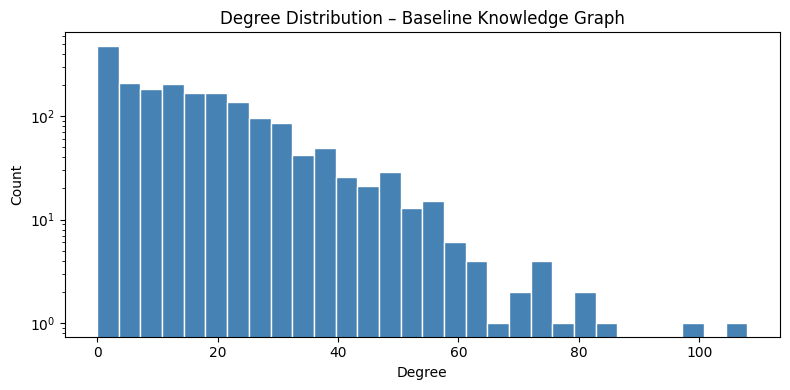

In [23]:
# ============================================================
# 2.3 Network Metrics – Top nodes by degree centrality
# ============================================================

deg_centrality = nx.degree_centrality(G_baseline)
top_nodes = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)[:15]

print("Top-15 nodes by degree centrality:")
print(f"{'Node':<40} {'Centrality':>10} {'Popularity':>10} {'Trend':>8}")
print("-" * 70)
for node_id, score in top_nodes:
    attrs = G_baseline.nodes[node_id]
    print(f"{attrs['name']:<40} {score:>10.4f} "
          f"{attrs['popularity']:>10.3f} {attrs['trend']:>8.1f}")

top_node_ids = [n for n, _ in top_nodes]

# Degree distribution
degrees = [d for _, d in G_baseline.degree()]
plt.figure(figsize=(8, 4))
plt.hist(degrees, bins=30, color="steelblue", edgecolor="white")
plt.title("Degree Distribution – Baseline Knowledge Graph")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.yscale("log")
plt.tight_layout()
plt.show()

**Transformer** is the most central node (0.056), confirming its role as a
foundational concept across AI research. Interestingly, the top-15 also
includes industrial companies such as **Bridgestone Corp**, **Mitsubishi Corp**,
and **Honeywell**, reflecting the dataset's coverage of AI applications in
manufacturing and automotive sectors.

The degree distribution follows a **power-law pattern** (log-scale y-axis),
which is characteristic of real-world knowledge graphs: a few hub nodes
dominate, while most nodes have very few connections.

## 2.4 Trend Analysis: Rising vs. Declining AI Concepts

The `trend` field in the API indicates how interest in a concept has changed
recently (positive = growing, negative = declining). We visualise the top 10
rising and top 10 declining concepts to understand which areas of AI are
gaining or losing momentum in the media.

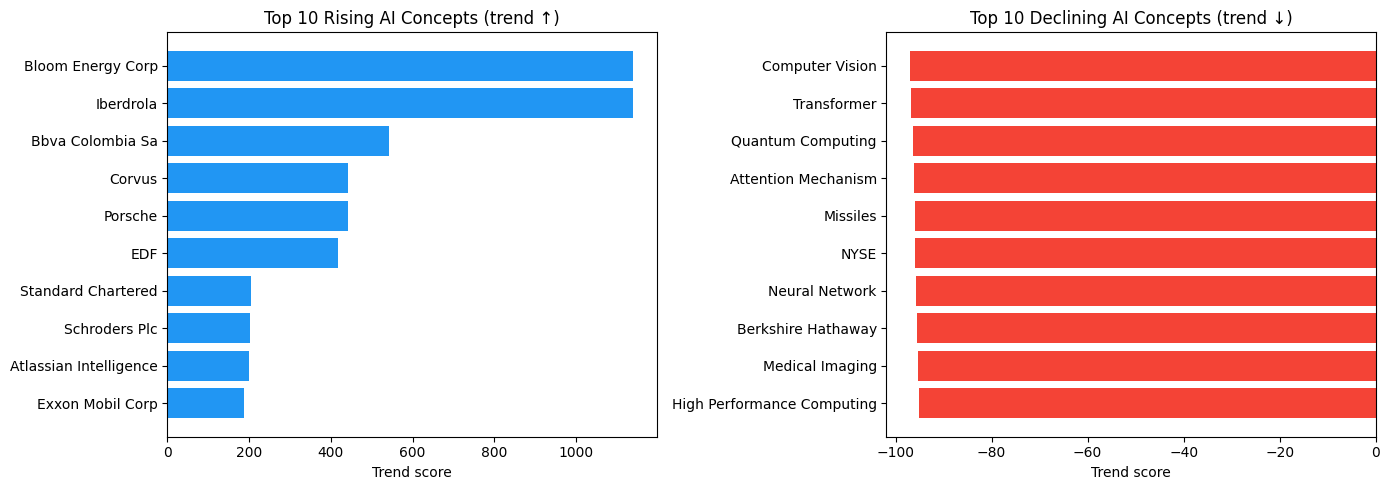

In [24]:
# ============================================================
# 2.4 Trend Analysis – Rising vs Declining AI concepts
# ============================================================

node_df = pd.DataFrame([
    {
        "nodeId"    : n,
        "name"      : d["name"],
        "type"      : d["type"],
        "popularity": d["popularity"],
        "trend"     : d["trend"],
        "activity"  : d["activity"],
    }
    for n, d in G_baseline.nodes(data=True)
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 rising
rising = node_df.nlargest(10, "trend")
axes[0].barh(rising["name"], rising["trend"], color="#2196F3")
axes[0].set_title("Top 10 Rising AI Concepts (trend ↑)")
axes[0].set_xlabel("Trend score")
axes[0].invert_yaxis()

# Top 10 declining
declining = node_df.nsmallest(10, "trend")
axes[1].barh(declining["name"], declining["trend"], color="#F44336")
axes[1].set_title("Top 10 Declining AI Concepts (trend ↓)")
axes[1].set_xlabel("Trend score")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

The **rising** concepts are dominated by energy and finance companies
(**Bloom Energy Corp**, **Iberdrola**, **BBVA**), suggesting growing AI
adoption in sustainability and fintech sectors.

On the declining side, core AI techniques like **Computer Vision**,
**Transformer**, **Quantum Computing**, and **Neural Network** show negative
trends. Not because they are less important, but likely because they have
become *established* topics that generate less novelty-driven media coverage.

## 2.5 Subgraph Visualisation – Top-5 Hubs

We extract the ego-graphs of the 5 most connected nodes and visualise them
together. Node size encodes popularity, node colour encodes trend
(blue = rising, red = declining), and edge width encodes connection strength.

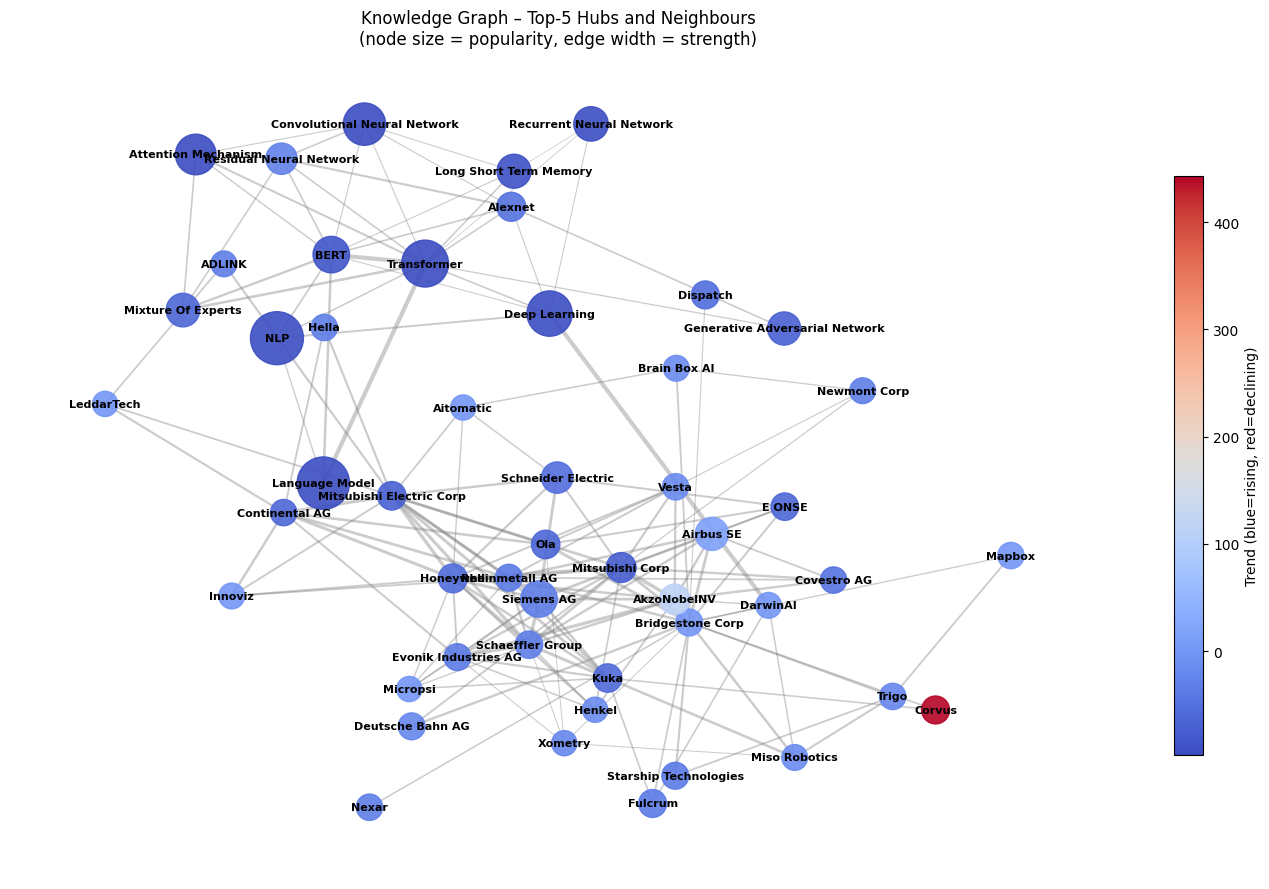

Subgraph: 50 nodes, 151 edges


In [27]:
# ============================================================
# 2.5 Visualise subgraph of top-5 most connected nodes
# Node size  = popularity
# Node color = trend (blue=rising, red=declining)
# Edge width = strength
# ============================================================

TOP_N = 5
subgraph_nodes = set(top_node_ids[:TOP_N])
for n in top_node_ids[:TOP_N]:
    if n in G_baseline:
        neighbours = list(G_baseline.neighbors(n))[:12]
        subgraph_nodes.update(neighbours)

SG = G_baseline.subgraph(subgraph_nodes).copy()
pos = nx.spring_layout(SG, seed=42, k=0.6)

# Node colours based on trend (normalised to 0-1)
trends    = np.array([SG.nodes[n]["trend"] for n in SG.nodes()])
norm      = plt.Normalize(vmin=trends.min(), vmax=trends.max())
cmap      = cm.coolwarm
colors    = [cmap(norm(t)) for t in trends]

# Node sizes based on popularity
sizes     = [300 + SG.nodes[n]["popularity"] * 1500 for n in SG.nodes()]

# Edge widths based on strength
widths    = [SG[u][v].get("strength", 0.3) * 3 for u, v in SG.edges()]

labels    = {n: SG.nodes[n]["name"] for n in SG.nodes()}

plt.figure(figsize=(14, 9))
nx.draw_networkx_nodes(SG, pos, node_color=colors, node_size=sizes, alpha=0.9)
nx.draw_networkx_edges(SG, pos, width=widths, alpha=0.4, edge_color="grey")
nx.draw_networkx_labels(SG, pos, labels=labels, font_size=8, font_weight="bold")

fig = plt.gcf()
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=plt.gca(), label="Trend (blue=rising, red=declining)", shrink=0.7)
plt.title(f"Knowledge Graph – Top-{TOP_N} Hubs and Neighbours\n"
          f"(node size = popularity, edge width = strength)")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"Subgraph: {SG.number_of_nodes()} nodes, {SG.number_of_edges()} edges")

The subgraph shows **50 nodes and 151 edges**. The graph reveals two clear
clusters: a **technical AI cluster** in the upper half (Transformer, BERT, NLP,
Deep Learning, Neural Networks) and an **industrial/automotive cluster** in the
lower half (Mitsubishi, Siemens, Honeywell, Bosch, Continental AG).

**Corvus** stands out as the only clearly rising node (red), while most hub
nodes are declining (blue), consistent with the trend analysis above. The
strong edges between NLP, Transformer, and BERT confirm their conceptual
similarity in the graph.

## 2.6 Entity Lookup for RAG

To enable graph-aware retrieval in Section 3, we build a dictionary that maps
each KG entity name to the passage IDs where it is mentioned. This allows the
RAG system to boost passages that contain entities relevant to a query.

In [29]:
# ============================================================
# 2.6 Build entity lookup for RAG (used in Section 3)
# ============================================================

# Generic terms to exclude – too broad to be meaningful
STOPWORDS_KG = {
    "models", "other", "use cases", "solutions", "model",
    "data", "system", "systems", "network", "networks",
    "technology", "technologies", "platform", "platforms",
    "tool", "tools", "service", "services", "application",
    "applications", "framework", "frameworks"
}

entity_to_passages = {}

for node_id, attrs in G_baseline.nodes(data=True):
    name = attrs["name"]

    # Skip short names and generic terms
    if len(name) < 4:
        continue
    if name.lower() in STOPWORDS_KG:
        continue

    name_lower = name.lower()
    hits = qa_df[
        qa_df["passage"].str.lower().str.contains(
            r'\b' + re.escape(name_lower) + r'\b', na=False
        )
    ]["passage_id"].tolist()

    if hits:
        entity_to_passages[name] = hits

# Deduplicate case variants – keep the one with more hits
# e.g. keep 'NVIDIA' (32) and drop 'Nvidia' (32) -> merge both
seen_lower = {}
for name, pids in entity_to_passages.items():
    key = name.lower()
    if key not in seen_lower or len(pids) > len(seen_lower[key][1]):
        seen_lower[key] = (name, pids)

entity_to_passages = {name: pids for name, pids in seen_lower.values()}

print(f"KG entities matched in passages : {len(entity_to_passages):,} / {G_baseline.number_of_nodes()} total")
print("\nTop 10 most-mentioned entities:")
top_ents = sorted(entity_to_passages.items(),
                  key=lambda x: len(x[1]), reverse=True)[:10]
for ent, pids in top_ents:
    print(f"  '{ent}' → {len(pids)} passages")

KG entities matched in passages : 67 / 1942 total

Top 10 most-mentioned entities:
  'Generative AI' → 36 passages
  'NVIDIA' → 32 passages
  'OpenAI' → 24 passages
  'Google' → 20 passages
  'Microsoft' → 20 passages
  'Robotics' → 16 passages
  'Healthcare' → 12 passages
  'Anthropic' → 12 passages
  'ChatGPT' → 12 passages
  'Planning' → 12 passages


After filtering generic terms and deduplicating case variants, **67 meaningful
entities** from the Knowledge Graph were matched in our passage collection.
The top entities reflect the core players and topics of the AI media discourse:
**Generative AI** (36 passages) is the most frequently mentioned concept,
followed by major tech companies **NVIDIA** (32), **OpenAI** (24), **Google**
and **Microsoft** (20 each). Domain-specific topics like **Robotics**,
**Healthcare**, and **ChatGPT** also appear frequently, confirming that our
passage selection covers a diverse range of AI subfields. These 67 entities
will be used in Section 3 to boost retrieval when a user query mentions
a concept present in the Knowledge Graph.

# 3. RAG Implementation

*Lead: Bianca - Review:...*

We implement a Retrieval-Augmented Generation (RAG) system that combines
dense vector retrieval with the Knowledge Graph from Section 2. We compare
three retrieval strategies:

| Mode | Description |
|---|---|
| `text_only` | Pure dense retrieval via sentence embeddings + FAISS |
| `kg_baseline` | Dense retrieval + entity boost using the baseline KG from the API |
| `kg_stage1` | Dense retrieval + entity boost using the Stage 1 KG (optional) |

All three modes use the same GPT-4o-mini generator. Only the retrieval
context differs, making the comparison fair.

## 3.1 Install RAG dependencies

In [30]:
# ============================================================
# 3.1 Install RAG dependencies
# ============================================================
!pip install sentence-transformers faiss-cpu --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 56.5 MB/s eta 0:00:00


## 3.2 Build Vector Index over Passages

We encode all passages using the lightweight `all-MiniLM-L6-v2`
sentence-transformer model (384 dimensions) and store them in a FAISS
index for fast cosine similarity search. The model runs on CPU and
requires no API calls.

In [31]:
# ============================================================
# 3.2 Build vector index over passages
# ============================================================
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss

EMBED_MODEL = "all-MiniLM-L6-v2"

# Deduplicated passage table
passages_df = qa_df.drop_duplicates(subset=["passage_id"])[
    ["passage_id", "passage", "title", "sampled_topic"]
].copy()
passages_df = passages_df.dropna(subset=["passage"]).reset_index(drop=True)

print(f"Passages to index: {len(passages_df)}")
print(f"Embedding model  : {EMBED_MODEL}")

embedder = SentenceTransformer(EMBED_MODEL)
passage_texts = passages_df["passage"].tolist()

passage_embeddings = embedder.encode(
    passage_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,  # enables cosine via inner product
)

dim = passage_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dim)
faiss_index.add(passage_embeddings)

print(f"\nFAISS index built: {faiss_index.ntotal} vectors, dim={dim}")

Passages to index: 64
Embedding model  : all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


FAISS index built: 64 vectors, dim=384


The model encoded all **64 unique passages** into 384-dimensional vectors in
under a minute on CPU. The `UNEXPECTED` warning for `embeddings.position_ids`
can be safely ignored. It is a known compatibility note when loading
cross-architecture models and does not affect embedding quality.

## 3.3 Retrieval Functions

We implement two retrieval strategies:

- **Text-only**: ranks passages purely by cosine similarity to the query embedding
- **KG-boosted**: fetches 20 candidate passages by dense similarity, then
  re-scores them by checking how many KG entities from the query appear in
  each passage. Final score = dense score + 0.15 × entity hit rate.

In [32]:
# ============================================================
# 3.3 Retrieval functions
# ============================================================

def retrieve_text_only(query: str, top_k: int = 5) -> list:
    """Pure dense retrieval – cosine similarity via FAISS."""
    q_emb = embedder.encode([query], normalize_embeddings=True)
    scores, idxs = faiss_index.search(q_emb, top_k)
    results = []
    for score, idx in zip(scores[0], idxs[0]):
        row = passages_df.iloc[idx]
        results.append({
            "passage_id" : row["passage_id"],
            "passage"    : row["passage"],
            "title"      : row["title"],
            "topic"      : row["sampled_topic"],
            "score"      : float(score),
            "kg_boost"   : 0.0,
        })
    return results


def retrieve_with_kg(
    query: str,
    graph,
    entity_lookup: dict,
    top_k: int = 5,
    kg_boost_weight: float = 0.15,
    candidate_k: int = 20,
) -> list:
    """
    Entity-anchored retrieval:
    1. Fetch candidate_k passages by dense similarity
    2. Count how many KG entities from the query appear in each passage
    3. Re-score: final = dense_score + kg_boost_weight * entity_hit_rate
    4. Return top_k by final score
    """
    q_emb = embedder.encode([query], normalize_embeddings=True)
    scores, idxs = faiss_index.search(q_emb, candidate_k)

    query_lower = query.lower()
    matched_entities = [
        name for name in entity_lookup
        if name.lower() in query_lower
    ]

    results = []
    for dense_score, idx in zip(scores[0], idxs[0]):
        row = passages_df.iloc[idx]
        pid = row["passage_id"]

        kg_hit = sum(
            1 for name in matched_entities
            if pid in entity_lookup.get(name, [])
        )
        kg_boost    = kg_hit / max(len(matched_entities), 1)
        final_score = float(dense_score) + kg_boost_weight * kg_boost

        results.append({
            "passage_id" : pid,
            "passage"    : row["passage"],
            "title"      : row["title"],
            "topic"      : row["sampled_topic"],
            "score"      : final_score,
            "kg_boost"   : kg_boost,
        })

    results.sort(key=lambda x: x["score"], reverse=True)
    return results[:top_k]


def build_kg_retriever(graph, entity_lookup, top_k=5):
    """Returns a retriever function for a given KG config."""
    if graph is None:
        print("  [WARN] No graph provided – falling back to text_only")
        return lambda q: retrieve_text_only(q, top_k=top_k)
    return lambda q: retrieve_with_kg(
        q, graph, entity_lookup, top_k=top_k
    )


# Instantiate all three retrievers
retriever_text_only   = lambda q: retrieve_text_only(q, top_k=5)
retriever_kg_baseline = build_kg_retriever(G_baseline, entity_to_passages)

# Stage 1 KG – only if your team produced one in Stage 1
# If not available, it falls back to text_only automatically
G_stage1 = None  # replace with your Stage 1 graph if available
retriever_kg_stage1 = build_kg_retriever(G_stage1, entity_to_passages)

print("Retrievers ready:")
print("  ✓ text_only")
print("  ✓ kg_baseline  (API Knowledge Graph)")
print("  ✓ kg_stage1   ", "– Stage 1 KG" if G_stage1 else "– fallback to text_only")

  [WARN] No graph provided – falling back to text_only
Retrievers ready:
  ✓ text_only
  ✓ kg_baseline  (API Knowledge Graph)
  ✓ kg_stage1    – fallback to text_only


The three retrievers share the same FAISS index but differ in how they score
candidates. `kg_stage1` falls back to `text_only` since no Stage 1 graph is
available yet. This can be updated once the Stage 1 KG is integrated.

## 3.4 Generator Function

The generator takes a question and the top-k retrieved passages and calls
GPT-4o-mini to produce a grounded answer. The system prompt strictly
instructs the model to use **only** the provided context (not its own
knowledge) ensuring that answers are traceable to the retrieved passages.

In [35]:
# ============================================================
# 3.4 Generator function (GPT-4o-mini)
# ============================================================

def generate_answer(
    question: str,
    context_passages: list,
    model: str = "gpt-4o-mini",
    max_tokens: int = 300,
) -> str:
    """
    Generate a grounded answer from retrieved passages.
    The model is instructed to use ONLY the provided context.
    KG entities found in the query are highlighted in the prompt.
    """
    context_str = "\n\n".join(
        f"[{i+1}] {p['passage']}" for i, p in enumerate(context_passages)
    )

    # Add KG entities that were boosted (kg_boost > 0)
    kg_entities = [
        p["passage_id"] for p in context_passages if p.get("kg_boost", 0) > 0
    ]
    kg_hint = ""
    if kg_entities:
        # Find which entity names matched
        matched = [
            name for name, pids in entity_to_passages.items()
            if any(pid in pids for pid in kg_entities)
        ]
        if matched:
            kg_hint = (
                f"\n\nRelevant Knowledge Graph entities identified in this query: "
                f"{', '.join(matched[:5])}. "
                f"Where possible, reference these entities in your answer."
            )

    prompt = (
        "You are a helpful assistant specialized in AI trends.\n"
        "Use ONLY the provided context passages to answer the question.\n"
        "If the answer is not in the context, say: 'Not enough information.'\n"
        "Be concise and factual (2-4 sentences).\n\n"
        f"Context:\n{context_str}"
        f"{kg_hint}\n\n"
        f"Question: {question}\n"
        "Answer:"
    )
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=max_tokens,
    )
    return response.choices[0].message.content.strip()

The generator uses `temperature=0.0` to ensure deterministic, reproducible
answers. The strict system prompt prevents the model from drawing on its own
training knowledge, which is essential for a fair RAG evaluation. Answers
must be grounded in the retrieved passages only.

## 3.5 End-to-End Pipeline & Smoke Test

We combine retrieval and generation into a single `rag_answer()` function
and run a quick smoke test with one sample question across all three modes
to verify the pipeline works end-to-end before the full evaluation.

In [34]:
# ============================================================
# 3.5 End-to-end pipeline & smoke test
# ============================================================

def rag_answer(question: str, retriever, **gen_kwargs) -> dict:
    """Full RAG pipeline: retrieve → generate."""
    retrieved = retriever(question)
    answer    = generate_answer(question, retrieved, **gen_kwargs)
    return {
        "question"              : question,
        "answer_generated"      : answer,
        "retrieved_passage_ids" : [r["passage_id"] for r in retrieved],
        "top_passage"           : retrieved[0]["passage"] if retrieved else "",
        "kg_boosts"             : [r["kg_boost"] for r in retrieved],
    }


# Smoke test with one sample question
sample_row = qa_df.sample(1, random_state=7).iloc[0]
test_q     = sample_row["question"]
test_gold  = sample_row["answer_gold"]

print("Question   :", test_q)
print("Gold answer:", test_gold)
print()

for name, retriever in [
    ("text_only",   retriever_text_only),
    ("kg_baseline", retriever_kg_baseline),
    ("kg_stage1",   retriever_kg_stage1),
]:
    res = rag_answer(test_q, retriever)
    print(f"[{name}]")
    print(f"  Answer    : {res['answer_generated']}")
    print(f"  Retrieved : {res['retrieved_passage_ids']}")
    print(f"  KG boosts : {res['kg_boosts']}")
    print()

Question   : What do algorithmic hiring systems analyze to create models of ideal candidates?
Gold answer: Machine learning algorithms analyze data from current high-performing employees.

[text_only]
  Answer    : Algorithmic hiring systems analyze data from current high-performing employees to create models of ideal candidates for similar roles. They identify patterns in backgrounds, skills, and behaviors that correlate with successful employees.
  Retrieved : ['p_038', 'p_044', 'p_051', 'p_053', 'p_059']
  KG boosts : [0.0, 0.0, 0.0, 0.0, 0.0]

[kg_baseline]
  Answer    : Algorithmic hiring systems analyze data from current high-performing employees to create models of ideal candidates for similar roles. They identify patterns in backgrounds, skills, and behaviors that correlate with successful employees.
  Retrieved : ['p_038', 'p_044', 'p_051', 'p_053', 'p_059']
  KG boosts : [0.0, 0.0, 0.0, 0.0, 0.0]

[kg_stage1]
  Answer    : Algorithmic hiring systems analyze data from current 

The smoke test confirms the full pipeline works end-to-end. For this particular
question (*"What do algorithmic hiring systems analyze to create models of ideal
candidates?"*), all three modes retrieved the same passages and produced nearly
identical answers. Both consistent with the gold answer.

The KG boosts are all `0.0` because the query contains no entities from the
Knowledge Graph (e.g. no company names like *OpenAI* or concepts like
*Generative AI*). The KG boost will make a measurable difference in Section 4
for